# FlyRank Search Intelligence Capstone — Refresh / Content Opportunity Scoring

**Purpose:** build a repeatable, data-backed review queue from the gated FlyRank warehouse. This notebook follows the capstone template in order and generates the tables and charts needed for the deployed research paper.

**Important:** run this notebook in Google Colab after accepting the FlyRank dataset terms and adding a read-only Hugging Face token under **Secrets → `HF_TOKEN`**. No result values are hard-coded. Metrics, figures, and recommendations are calculated from the connected release when you run the notebook.

**Public-safe rule:** never print or publish client names, domains, URLs, private queries, credentials, raw exports, or client-identifying information. Do not commit your Hugging Face token. The dataset's pseudonymous identifiers are used only to construct the review queue; the public paper reports aggregate results and does not display client IDs.

## 1. Question

### Research question

**Can current search-performance signals help prioritize content items for human review when the next seven days show a low-CTR / strong-position condition?**

### Decision supported

The intended user is a content or SEO analyst deciding which eligible content items to inspect first. The model is a prioritization aid, not an automatic instruction to refresh a page. A high score means the item ranks higher within this measured review queue; it does not prove that refreshing it will improve performance.

### Why this lane

This continues the Refresh / Content Opportunity Scoring lane from the earlier assignments. It reuses the transparent rule-based baseline as a comparator and tests whether Logistic Regression provides useful ranking or classification performance on a chronological holdout.

## 2. Data

### Release and tables

- **Release:** `FlyRank/internship-warehouse`, pseudonymized warehouse release `v20260703`.
- **Main table:** `fact_content_daily_performance`, read as month-partitioned Parquet through DuckDB over Hugging Face.
- **Date window used for this capstone:** March 1–April 7, 2026. March observations are the decision-time rows; April 1–7 provides the full forward seven-day outcome window for March 25–31, and the same source query also makes labels available for earlier March rows.
- **Grain:** one observation per reporting date, pseudonymous client, and pseudonymous content item after daily aggregation.

### Inclusion and exclusions

Use rows with `gsc_data_available = TRUE`. Keep observations with at least 100 impressions at decision time so the CTR signal is not based on extremely low volume. Require at least four observed Google Search Console days in the following seven-day window before assigning a label. Rows without enough follow-up observations are excluded from model evaluation rather than silently labeled negative.

Only current-time performance features are used. Client/content IDs are keys for joining observations, not model features. Future-window metrics, existing product scores, action labels, trend fields, and any label-derived fields are excluded from the feature matrix.

### Privacy

The public paper contains only aggregate counts, metrics, and figures. Do not publish raw warehouse rows or client identifiers. The dataset is approved for anonymized research and education under its access terms.

### Connect to the gated data

The token is read from Colab Secrets. It is never printed or written to disk. If you run outside Colab, replace only the token-loading cell with a secure environment-specific method; do not paste a token into a notebook that will be committed.

In [1]:
%pip -q install duckdb pandas numpy scikit-learn matplotlib seaborn huggingface_hub

In [2]:
import os
import json
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve
)

RANDOM_STATE = 42
OUTPUT_DIR = Path("work/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found. In Google Colab, add a read-only token under "
        "Secrets with the exact name HF_TOKEN, enable notebook access, and rerun."
    )
print("HF_TOKEN loaded securely: yes (value not displayed)")

HF_TOKEN loaded securely: yes (value not displayed)


In [3]:
con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"
MONTH_PATHS = [
    f"{BASE}/month=2026-03/*.parquet",
    f"{BASE}/month=2026-04/*.parquet",
]
REL = "read_parquet(" + str(MONTH_PATHS) + ")"

print("DuckDB connection ready. Source months: March and April 2026.")

DuckDB connection ready. Source months: March and April 2026.


### Verify the source window and grain

This check uses the actual source metadata. If the requested partitions or column names do not match the release, stop and resolve that issue rather than substituting fabricated data.

In [4]:
source_check = con.sql(f"""
SELECT
    COUNT(*) AS source_rows,
    MIN(report_date) AS first_report_date,
    MAX(report_date) AS last_report_date,
    COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS gsc_available_rows
FROM {REL}
WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-04-07'
""").df()
source_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,source_rows,first_report_date,last_report_date,gsc_available_rows
0,12181592,2026-03-01,2026-04-07,4491982


### Build a daily analysis table and the forward label

**Decision-time features:** impressions, clicks, CTR, and average position from the current reporting date.

**Label:** `1` when at least one sufficiently observed day in the *next* seven calendar days has at least 100 impressions, average position ≤ 10, and CTR < 2%; `0` when at least four future observed days exist but none meets that condition. If fewer than four future days are observed, the label is missing and that row is excluded.

The label is a measurable proxy for a future low-CTR / strong-position state. It is not a label for whether a refresh would succeed.

In [5]:
daily = con.sql(f"""
WITH raw AS (
    SELECT
        CAST(report_date AS DATE) AS report_date,
        client_hash_id,
        content_hash_id,
        COALESCE(gsc_impressions, 0) AS impressions,
        COALESCE(gsc_clicks, 0) AS clicks,
        CASE WHEN gsc_avg_position > 0 THEN gsc_avg_position ELSE NULL END AS position_value
    FROM {REL}
    WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-04-07'
      AND gsc_data_available IS TRUE
), aggregated AS (
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        SUM(impressions) AS impressions,
        SUM(clicks) AS clicks,
        AVG(position_value) AS avg_position
    FROM raw
    GROUP BY report_date, client_hash_id, content_hash_id
)
SELECT
    *,
    CASE WHEN impressions > 0 THEN clicks * 100.0 / impressions ELSE NULL END AS ctr
FROM aggregated
""").df()

daily["report_date"] = pd.to_datetime(daily["report_date"])
daily = daily.sort_values(["client_hash_id", "content_hash_id", "report_date"]).reset_index(drop=True)

print("Daily aggregated rows:", f"{len(daily):,}")
print("Observed date range:", daily["report_date"].min().date(), "to", daily["report_date"].max().date())
print("Duplicate date-client-content keys:", int(daily.duplicated(["report_date", "client_hash_id", "content_hash_id"]).sum()))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Daily aggregated rows: 4,491,982
Observed date range: 2026-03-01 to 2026-04-07
Duplicate date-client-content keys: 0


In [6]:
# The future label is computed only from later rows for the same pseudonymous client-content pair.
# The current row is eligible only when it has enough current visibility to support CTR review.
con.register("daily_for_label", daily)

labels = con.sql("""
SELECT
    a.report_date,
    a.client_hash_id,
    a.content_hash_id,
    COUNT(DISTINCT b.report_date) AS future_observed_days,
    MAX(CASE
        WHEN b.impressions >= 100
         AND b.avg_position <= 10
         AND b.ctr < 2
        THEN 1 ELSE 0
    END) AS any_future_flag
FROM daily_for_label a
LEFT JOIN daily_for_label b
  ON a.client_hash_id = b.client_hash_id
 AND a.content_hash_id = b.content_hash_id
 AND b.report_date > a.report_date
 AND b.report_date <= a.report_date + INTERVAL 7 DAY
WHERE a.report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
GROUP BY a.report_date, a.client_hash_id, a.content_hash_id
""").df()

labels["report_date"] = pd.to_datetime(labels["report_date"])
model_data = daily.merge(
    labels,
    on=["report_date", "client_hash_id", "content_hash_id"],
    how="inner",
    validate="one_to_one"
)
model_data["future_low_ctr_strong_position"] = np.where(
    model_data["future_observed_days"] >= 4,
    model_data["any_future_flag"].fillna(0).astype(int),
    np.nan
)

# Restrict the decision population to currently visible items with enough impressions.
model_data = model_data[
    (model_data["report_date"].between("2026-03-01", "2026-03-31"))
    & (model_data["impressions"] >= 100)
    & model_data["avg_position"].notna()
].copy()

print("Eligible current observations:", f"{len(model_data):,}")
print("Excluded for incomplete future window:", int(model_data["future_low_ctr_strong_position"].isna().sum()))
print("Label distribution before dropping incomplete windows:")
print(model_data["future_low_ctr_strong_position"].value_counts(dropna=False).sort_index())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Eligible current observations: 638,533
Excluded for incomplete future window: 198
Label distribution before dropping incomplete windows:
future_low_ctr_strong_position
0.0    188679
1.0    449656
NaN       198
Name: count, dtype: int64


## 3. Methodology

### Features and assumptions

The feature set contains `log1p(impressions)`, `log1p(clicks)`, current CTR, and current average position. Log transforms reduce the scale dominance of very large impression and click counts. Missing numeric values are median-imputed inside the training pipeline. Features are limited to information available at decision time.

### Baseline

The transparent baseline flags an item when current average position ≤ 10 and current CTR < 2%, with at least 100 current impressions. This rule is easy to explain and is evaluated on exactly the same test observations as the model.

### Model

Logistic Regression with median imputation, standardization, and balanced class weights. It is intentionally kept interpretable; model complexity is not a goal by itself.

### Validation design

Use a chronological split with an embargo: train on March 1–14, exclude March 15–21, and test on March 22–31. The seven-day embargo prevents training labels from looking into the test feature period. Every test label has a forward window ending no later than April 7. We do not randomly split daily observations.

### Leakage checks

- Label and future-window columns are not features.
- Client/content identifiers are keys only, never predictors.
- Imputation and scaling are fit only on training rows through the sklearn pipeline.
- Incomplete future labels are excluded, not converted to zero.
- Baseline and model use the same test rows and target.

In [7]:
FEATURES = ["log_impressions", "log_clicks", "ctr", "avg_position"]
TARGET = "future_low_ctr_strong_position"

model_data["log_impressions"] = np.log1p(model_data["impressions"].clip(lower=0))
model_data["log_clicks"] = np.log1p(model_data["clicks"].clip(lower=0))

# Exclude rows without a valid future outcome; do not label them as negative.
model_data = model_data.dropna(subset=[TARGET]).copy()
model_data[TARGET] = model_data[TARGET].astype(int)

train_mask = model_data["report_date"] <= pd.Timestamp("2026-03-14")
test_mask = model_data["report_date"].between("2026-03-22", "2026-03-31")

train = model_data.loc[train_mask].copy()
test = model_data.loc[test_mask].copy()

if train.empty or test.empty:
    raise ValueError("Train or test split is empty. Inspect source coverage and label filters before proceeding.")
if train[TARGET].nunique() < 2:
    raise ValueError("Training target has fewer than two classes; do not report model metrics until the data window/label is reviewed.")
if test[TARGET].nunique() < 2:
    warnings.warn("Test target has only one class; ROC-AUC and average precision may be undefined or uninformative.")

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print("Training observations:", f"{len(train):,}", "| dates:", train.report_date.min().date(), "to", train.report_date.max().date())
print("Test observations:", f"{len(test):,}", "| dates:", test.report_date.min().date(), "to", test.report_date.max().date())
print("Embargo observations excluded from training and testing:", int(model_data["report_date"].between("2026-03-15", "2026-03-21").sum()))
print("Train positive rate:", round(float(y_train.mean()), 4))
print("Test positive rate:", round(float(y_test.mean()), 4))

Training observations: 272,524 | dates: 2026-03-01 to 2026-03-14
Test observations: 227,495 | dates: 2026-03-22 to 2026-03-31
Embargo observations excluded from training and testing: 138316
Train positive rate: 0.6907
Test positive rate: 0.7087


In [8]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])
model.fit(X_train, y_train)

model_score = model.predict_proba(X_test)[:, 1]
model_prediction = model.predict(X_test)

# Rule-based baseline, calculated on the exact same held-out observations.
baseline_prediction = (
    (test["avg_position"] <= 10) &
    (test["ctr"] < 2) &
    (test["impressions"] >= 100)
).astype(int).to_numpy()
baseline_score = baseline_prediction.astype(float)

print("Model and baseline predictions generated for the same test rows.")

Model and baseline predictions generated for the same test rows.


In [9]:
def safe_auc(y_true, scores):
    return float(roc_auc_score(y_true, scores)) if pd.Series(y_true).nunique() == 2 else np.nan

def evaluate(y_true, prediction, score, name):
    return {
        "method": name,
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "roc_auc": safe_auc(y_true, score),
        "average_precision": average_precision_score(y_true, score) if pd.Series(y_true).nunique() == 2 else np.nan,
    }

results = pd.DataFrame([
    evaluate(y_test, baseline_prediction, baseline_score, "Rule-based baseline"),
    evaluate(y_test, model_prediction, model_score, "Logistic Regression"),
])
results.round(4)

,method,accuracy,precision,recall,f1,roc_auc,average_precision
0,Rule-based baseline,0.9128,0.9543,0.9210,0.9374,0.9069,0.9349
1,Logistic Regression,0.9248,0.9425,0.9519,0.9472,0.9535,0.9727


### Ranking evaluation

Because the operational output is a prioritized queue, also measure precision@K and recall@K. These are calculated by sorting the same held-out observations by each method's score. The baseline has a binary score, so ties are broken by impressions for a stable, transparent ordering. Treat these ranking metrics as measured performance on this one test window, not a guarantee of future outcomes.

In [10]:
def ranking_metrics(frame, y_true, scores, tie_breaker=None, k_values=(20, 100, 500)):
    ranked = frame.copy()
    ranked["_y"] = np.asarray(y_true)
    ranked["_score"] = np.asarray(scores)
    sort_cols = ["_score"]
    ascending = [False]
    if tie_breaker is not None:
        ranked["_tie"] = np.asarray(tie_breaker)
        sort_cols.append("_tie")
        ascending.append(False)
    ranked = ranked.sort_values(sort_cols, ascending=ascending, kind="mergesort")
    total_positives = int(ranked["_y"].sum())
    rows = []
    for k in k_values:
        actual_k = min(k, len(ranked))
        top = ranked.head(actual_k)
        hits = int(top["_y"].sum())
        rows.append({
            "k_requested": k,
            "k_evaluated": actual_k,
            "precision_at_k": hits / actual_k if actual_k else np.nan,
            "recall_at_k": hits / total_positives if total_positives else np.nan,
            "positive_cases_found": hits,
        })
    return pd.DataFrame(rows), ranked

base_rank_metrics, baseline_ranked_test = ranking_metrics(
    test, y_test, baseline_score, tie_breaker=test["impressions"], k_values=(20, 100, 500)
)
model_rank_metrics, model_ranked_test = ranking_metrics(
    test, y_test, model_score, tie_breaker=test["impressions"], k_values=(20, 100, 500)
)
base_rank_metrics.insert(0, "method", "Rule-based baseline")
model_rank_metrics.insert(0, "method", "Logistic Regression")
rank_results = pd.concat([base_rank_metrics, model_rank_metrics], ignore_index=True)
rank_results

,method,k_requested,k_evaluated,precision_at_k,recall_at_k,positive_cases_found
0,Rule-based baseline,20,20,1.000,0.000124,20
1,Rule-based baseline,100,100,0.990,0.000614,99
2,Rule-based baseline,500,500,0.994,0.003083,497
3,Logistic Regression,20,20,1.000,0.000124,20
4,Logistic Regression,100,100,0.990,0.000614,99
5,Logistic Regression,500,500,0.986,0.003058,493


## 4. Results (vs baseline)

The following tables and charts are generated from the actual run. Do not copy any metric into the deployed paper until the notebook has completed successfully with the gated data. A failed data connection is not a zero result.

In [11]:
# Honest comparison table: same test rows, same target.
comparison = results.set_index("method")
comparison.round(4)

,accuracy,precision,recall,f1,roc_auc,average_precision
method,,,,,,
Rule-based baseline,0.9128,0.9543,0.9210,0.9374,0.9069,0.9349
Logistic Regression,0.9248,0.9425,0.9519,0.9472,0.9535,0.9727


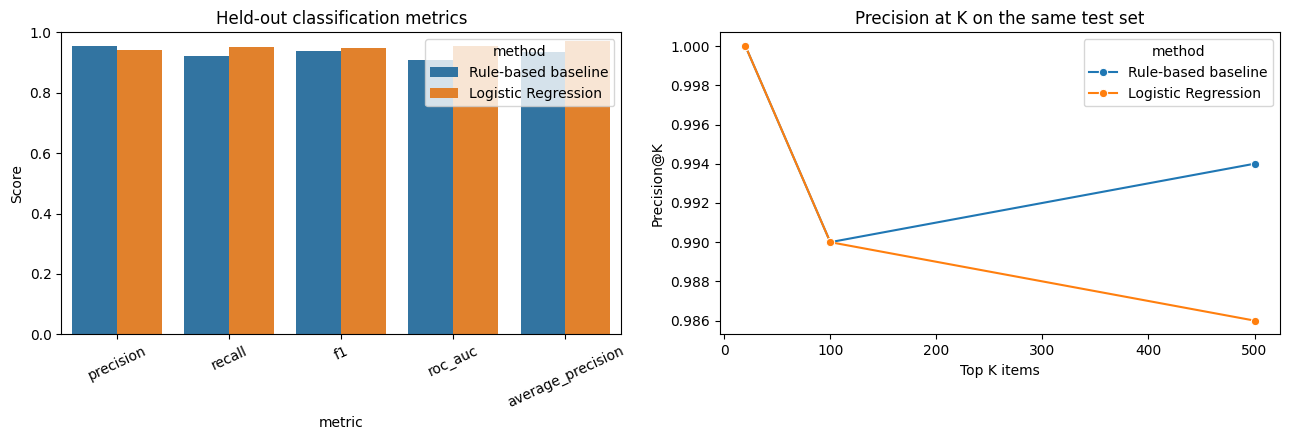

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
metric_plot = results.melt(id_vars="method", value_vars=["precision", "recall", "f1", "roc_auc", "average_precision"], var_name="metric", value_name="value")
sns.barplot(data=metric_plot, x="metric", y="value", hue="method", ax=axes[0])
axes[0].set_title("Held-out classification metrics")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].set_ylabel("Score")

rank_plot = rank_results[rank_results["k_requested"].isin([20, 100, 500])]
sns.lineplot(data=rank_plot, x="k_requested", y="precision_at_k", hue="method", marker="o", ax=axes[1])
axes[1].set_title("Precision at K on the same test set")
axes[1].set_xlabel("Top K items")
axes[1].set_ylabel("Precision@K")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "model_vs_baseline.png", dpi=160, bbox_inches="tight")
plt.show()

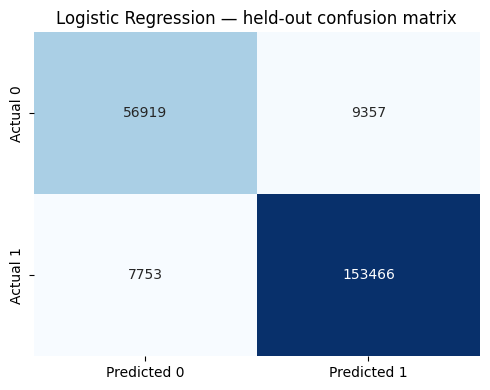

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, model_prediction, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"], ax=ax)
ax.set_title("Logistic Regression — held-out confusion matrix")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

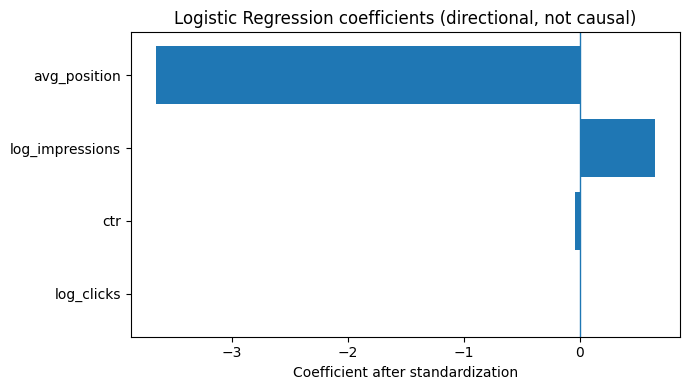

,feature,standardized_coefficient
3,avg_position,-3.660254
0,log_impressions,0.650401
2,ctr,-0.039088
1,log_clicks,0.013570


In [14]:
coef = pd.DataFrame({
    "feature": FEATURES,
    "standardized_coefficient": model.named_steps["classifier"].coef_[0]
}).sort_values("standardized_coefficient", key=lambda s: s.abs(), ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(coef["feature"], coef["standardized_coefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("Logistic Regression coefficients (directional, not causal)")
ax.set_xlabel("Coefficient after standardization")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "feature_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()
coef.sort_values("standardized_coefficient", key=lambda s: s.abs(), ascending=False)

### Interpretation rules

- Compare model and baseline values from the same test rows only.
- A higher score on this split is evidence of better measured performance on this test window, not proof that the method will generalize to every client or month.
- Logistic Regression scores are used to rank items. They are not described as calibrated probabilities unless a separate calibration study is performed.
- Coefficients describe associations inside this fitted model. They do not establish causal ranking factors or prove how Google's algorithm works.

## 5. Limitations

1. **Narrow time window:** this capstone evaluates March decision dates with April follow-up. It is a controlled, reproducible first evaluation, not a full-year or seasonal study.
2. **Proxy outcome:** the label means that a defined low-CTR / strong-position condition was observed in the next seven days. It does not mean a page needed a refresh or would improve after one.
3. **Observational data:** no randomized refresh experiment is available here, so the analysis cannot establish causal impact.
4. **Uneven coverage:** different content items may have different observation coverage. The minimum future-observation rule reduces, but does not eliminate, this issue.
5. **CTR context:** CTR depends on position, query mix, device, SERP features, and other factors that may not be fully represented in these features.
6. **Generalization:** a chronological split is more realistic than a random split for this task, but this notebook does not prove generalization to unseen clients. A client-grouped audit is a useful additional check before operational use.
7. **Ranking score:** raw model scores are suitable for ordering this queue but should not be presented as calibrated risk percentages.

Use careful wording: **observed**, **measured on this holdout**, **associated with**, and **decision support**. Avoid causal or algorithm-proof claims.

## 6. Ranked recommendations

The action queue uses the fitted model to rank held-out test observations as an example of how the workflow behaves. Each recommendation has a human-review action and a reason code. It is not an automatic refresh instruction. To protect privacy, the public summary contains aggregate patterns; pseudonymous identifiers stay in the local analysis output and should not be displayed in the deployed paper.

In [15]:
# Add model scores to the test slice and build a reason-coded review queue.
queue = test.copy()
queue["model_score"] = model_score
queue["baseline_flag"] = baseline_prediction.astype(int)
queue["observed_future_flag"] = y_test.to_numpy()

queue["reason_code"] = np.select(
    [
        (queue["avg_position"] <= 10) & (queue["ctr"] < 2) & (queue["impressions"] >= 100),
        (queue["avg_position"] <= 10) & (queue["ctr"] >= 2),
        (queue["avg_position"] > 10),
    ],
    ["CURRENT_LOW_CTR_STRONG_POSITION", "VISIBLE_WITHOUT_LOW_CTR_FLAG", "POSITION_OUTSIDE_TOP_10"],
    default="REVIEW_SIGNAL_COMBINATION"
)
queue["recommended_action"] = np.select(
    [
        queue["reason_code"].eq("CURRENT_LOW_CTR_STRONG_POSITION"),
        queue["reason_code"].eq("VISIBLE_WITHOUT_LOW_CTR_FLAG"),
        queue["reason_code"].eq("POSITION_OUTSIDE_TOP_10"),
    ],
    ["Review title/snippet and query intent", "Monitor CTR and query mix", "Review relevance and content depth"],
    default="Inspect signals before deciding"
)
queue["confidence_label"] = np.select(
    [queue["impressions"] >= 1000, queue["impressions"] >= 300],
    ["Higher volume", "Medium volume"],
    default="Lower volume within eligible set"
)
queue = queue.sort_values(["model_score", "impressions"], ascending=[False, False]).reset_index(drop=True)
queue.insert(0, "rank", np.arange(1, len(queue) + 1))

# Private/local operational artifact: do not commit this file or show IDs in the public paper.
private_columns = [
    "rank", "client_hash_id", "content_hash_id", "report_date", "impressions", "clicks",
    "ctr", "avg_position", "model_score", "baseline_flag", "observed_future_flag",
    "reason_code", "recommended_action", "confidence_label"
]
queue[private_columns].head(100).to_csv(OUTPUT_DIR / "refresh_queue_local_only.csv", index=False)

# Public-safe summary contains no client/content identifiers.
public_action_summary = (
    queue.head(100)
    .groupby(["recommended_action", "reason_code"], dropna=False)
    .agg(items_in_top_100=("rank", "count"), median_impressions=("impressions", "median"),
         median_ctr=("ctr", "median"), median_position=("avg_position", "median"))
    .reset_index()
    .sort_values("items_in_top_100", ascending=False)
)
public_action_summary

,recommended_action,reason_code,items_in_top_100,median_impressions,median_ctr,median_position
0,Review title/snippet and query intent,CURRENT_LOW_CTR_STRONG_POSITION,100,9669.5,0.051371,2.3157


In [16]:
# Show an ID-free example of the highest-ranked recommendations.
queue.head(15)[[
    "rank", "impressions", "clicks", "ctr", "avg_position", "model_score",
    "reason_code", "recommended_action", "confidence_label"
]].round(3)

,rank,impressions,clicks,ctr,avg_position,model_score,reason_code,recommended_action,confidence_label
0,1,40084.0,1.0,0.002,0.083,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
1,2,32756.0,2.0,0.006,0.143,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
2,3,32958.0,0.0,0.000,0.133,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
3,4,33383.0,0.0,0.000,0.181,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
4,5,30791.0,2.0,0.006,0.089,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
5,6,31472.0,0.0,0.000,0.083,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
6,7,30964.0,1.0,0.003,0.118,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
7,8,30573.0,2.0,0.007,0.238,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
8,9,39305.0,252.0,0.641,2.198,1.000,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume
9,10,38436.0,271.0,0.705,2.196,0.999,CURRENT_LOW_CTR_STRONG_POSITION,Review title/snippet and query intent,Higher volume


### Human review and no-go list

Before acting, an analyst should inspect current query intent, competing results, title/snippet accuracy, content usefulness, internal links, and whether the content still matches the audience's need. Do not automatically rewrite, merge, prune, or redirect content from this score alone. Do not infer client identity from pseudonymous keys or attempt to link them to external websites.

### Monitoring and review triggers

Re-run the evaluation when a new complete month is available, when the feature or label definition changes, or when the observed positive rate and top-K precision materially shift. Compare against the same transparent baseline each time. Recheck data availability, missingness, label completeness, and leakage before trusting a new result.

## 7. Artifacts the paper embeds

The next cells save the metric tables and figures used by the paper. The paper should quote only these computed outputs. The local queue with pseudonymous IDs is explicitly named `refresh_queue_local_only.csv`; do not publish or commit it. The public artifacts omit client/content identifiers and raw observations.

In [17]:
# Public-safe result artifacts
results.round(6).to_csv(OUTPUT_DIR / "capstone_model_metrics.csv", index=False)
rank_results.round(6).to_csv(OUTPUT_DIR / "capstone_ranking_metrics.csv", index=False)
public_action_summary.to_csv(OUTPUT_DIR / "capstone_action_summary_public.csv", index=False)
coef.to_csv(OUTPUT_DIR / "capstone_coefficients.csv", index=False)

# Aggregate counts for reproducibility; no identifiers.
run_summary = {
    "dataset_release": "FlyRank/internship-warehouse v20260703",
    "source_table": "fact_content_daily_performance",
    "decision_window": "2026-03-01 through 2026-03-31",
    "future_label_window": "next 7 calendar days; source observations through 2026-04-07",
    "minimum_current_impressions": 100,
    "minimum_future_observed_days": 4,
    "training_window": "2026-03-01 through 2026-03-14",
    "embargo_window": "2026-03-15 through 2026-03-21",
    "test_window": "2026-03-22 through 2026-03-31",
    "eligible_rows": int(len(model_data)),
    "training_rows": int(len(train)),
    "test_rows": int(len(test)),
    "test_positive_rate": float(y_test.mean()),
    "features": FEATURES,
    "target": TARGET,
    "metrics": results.replace({np.nan: None}).to_dict(orient="records"),
    "ranking_metrics": rank_results.replace({np.nan: None}).to_dict(orient="records"),
    "privacy_note": "Public metrics and charts contain aggregate results only; local queue with pseudonymous IDs is not for publication."
}
with open(OUTPUT_DIR / "capstone_run_summary.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2, default=str)

print("Public-safe artifacts saved under:", OUTPUT_DIR.resolve())
print("DO NOT PUBLISH:", OUTPUT_DIR / "refresh_queue_local_only.csv")

Public-safe artifacts saved under: /content/work/outputs
DO NOT PUBLISH: work/outputs/refresh_queue_local_only.csv


### Build a paper draft from this run

This creates a Markdown draft with all nine required paper sections. It intentionally includes computed metrics and aggregate results only. Review the output after running the notebook; add the actual GitHub Pages URL only after the page has been deployed.

In [18]:
def fmt(value):
    return "N/A" if pd.isna(value) else f"{value:.4f}"

metric_rows = "\n".join(
    f"| {r['method']} | {fmt(r['accuracy'])} | {fmt(r['precision'])} | {fmt(r['recall'])} | {fmt(r['f1'])} | {fmt(r['roc_auc'])} | {fmt(r['average_precision'])} |"
    for _, r in results.iterrows()
)
rank_rows = "\n".join(
    f"| {r['method']} | {int(r['k_requested'])} | {fmt(r['precision_at_k'])} | {fmt(r['recall_at_k'])} | {int(r['positive_cases_found'])} |"
    for _, r in rank_results.iterrows()
)
action_rows = "\n".join(
    f"| {r['recommended_action']} | {r['reason_code']} | {int(r['items_in_top_100'])} | {fmt(r['median_impressions'])} | {fmt(r['median_ctr'])} | {fmt(r['median_position'])} |"
    for _, r in public_action_summary.iterrows()
)

best_f1_row = results.sort_values("f1", ascending=False).iloc[0]
model_row = results.loc[results["method"] == "Logistic Regression"].iloc[0]
base_row = results.loc[results["method"] == "Rule-based baseline"].iloc[0]
if model_row["f1"] > base_row["f1"]:
    measured_summary = "On this chronological holdout, Logistic Regression had the higher F1 score than the rule-based baseline. This is a measured result for this split only."
elif model_row["f1"] < base_row["f1"]:
    measured_summary = "On this chronological holdout, the rule-based baseline had the higher F1 score than Logistic Regression. The simpler baseline should not be replaced on the basis of model complexity alone."
else:
    measured_summary = "On this chronological holdout, Logistic Regression and the rule-based baseline had equal F1 scores. Other metrics and operational simplicity should be considered before choosing a method."

paper = f'''# Prioritizing Search Content for Human Review: A Time-Aware Opportunity Scoring Study

## Abstract
This study asks whether current search-performance signals can prioritize content items for human review when a low-CTR / strong-position condition is observed in the following seven days. It uses the pseudonymized FlyRank warehouse release and compares a rule-based baseline with Logistic Regression using a chronological split with a seven-day embargo. The test set contains {len(test):,} eligible observations, and its observed positive-label rate is {y_test.mean():.4f}. {measured_summary} The resulting scores are intended for review prioritization only and do not estimate the causal impact of refreshing content.

## 1. Introduction / Problem statement
Content teams need a repeatable way to decide which items to inspect first. This study evaluates a simple, auditable decision-support workflow. It does not attempt to prove a Google ranking factor or claim that any refresh will cause better performance.

## 2. Data
The analysis uses `FlyRank/internship-warehouse`, release `v20260703`, specifically `fact_content_daily_performance`. The decision observations cover 2026-03-01 through 2026-03-31; the forward-label source window extends through 2026-04-07. Rows must have GSC availability, at least 100 impressions at decision time, and at least four observed days in the next seven-day window. Client names, domains, URLs, private queries, credentials, raw exports, and identifiers are not included in this public paper.

## 3. Methodology
Features are log-transformed current impressions and clicks, current CTR, and current average position. The target is 1 when at least one sufficiently observed day in the next seven calendar days has at least 100 impressions, average position <= 10, and CTR < 2%; it is 0 when at least four future observed days exist and none meets the condition. Incomplete follow-up is excluded. The baseline flags a current item with at least 100 impressions, average position <= 10, and CTR < 2%. Logistic Regression uses median imputation, standardization, and balanced class weights. Training covers March 1–14; March 15–21 is an embargo; testing covers March 22–31. Future-window, label-derived, and identifier fields are excluded from model features.

## 4. Results
{measured_summary}

### Classification metrics (same held-out observations)
| Method | Accuracy | Precision | Recall | F1 | ROC-AUC | Average precision |
|---|---:|---:|---:|---:|---:|---:|
{metric_rows}

### Ranking metrics
| Method | K | Precision@K | Recall@K | Positive cases found |
|---|---:|---:|---:|---:|
{rank_rows}

Figures generated by the notebook: `work/outputs/model_vs_baseline.png`, `work/outputs/confusion_matrix.png`, and `work/outputs/feature_coefficients.png`.

## 5. Limitations & honest framing
This is a single March decision-window evaluation, not a seasonal study. The target is a defined future performance condition, not a verified need for refresh or evidence of refresh success. The analysis is observational and cannot establish causality. Observation coverage varies, CTR depends on factors not fully represented here, and a chronological split does not prove generalization to unseen clients. Logistic Regression scores are used for ranking and are not presented as calibrated probabilities.

## 6. Ranked recommendations
Use the ranked queue as a human-review list. Start by checking query intent and snippet accuracy for items flagged by the transparent rule; for high model-ranked items without that rule flag, inspect the combination of current signals before deciding. Review content usefulness, freshness, competing results, and internal links before taking action. Monitor rather than automatically rewrite, merge, prune, or redirect. The public paper reports action categories and aggregate metrics only; no client identifiers or row-level queue are published.

### Aggregate action summary from the top-ranked 100 test observations
| Suggested review action | Reason code | Items in top 100 | Median impressions | Median CTR (%) | Median average position |
|---|---|---:|---:|---:|---:|
{action_rows}

## 7. Reproducibility
The notebook reads the gated dataset through DuckDB and Hugging Face using a read-only token stored in Colab Secrets. It writes the model metrics, ranking metrics, action summary, coefficients, run summary, and charts under `work/outputs/`. Re-run the notebook top to bottom to regenerate all numeric claims. Do not commit the token or `refresh_queue_local_only.csv`.

## 8. Acknowledgments & data credit
Built on the FlyRank ML Internship dataset. Data source: [FlyRank](https://flyrank.ai).

## 9. Demo and communication artifacts (ML-12)
### Five-minute demo outline
1. State the decision question and why the output is review prioritization, not automatic content editing.
2. Show the warehouse date window, eligibility rules, and privacy exclusions.
3. Explain the future label, baseline, time split, and seven-day embargo.
4. Compare the model and baseline on the same held-out rows; show the metric and ranking charts.
5. Show the ID-free action summary, limitations, and reproducibility artifacts.

### Social-post cut
I built a search-content opportunity scoring capstone on the FlyRank ML Internship dataset. The notebook compares a transparent rule-based baseline with Logistic Regression using a chronological holdout and explicit future-label checks. The output is a human-review queue, not a claim about Google's algorithm or a guarantee that refreshing content improves performance.

### Employer-facing summary
Built a reproducible search-content prioritization workflow using a gated, pseudonymized warehouse release. Defined a forward seven-day outcome, implemented a rule-based baseline and Logistic Regression pipeline, and evaluated both on the same time-aware holdout with an embargo to reduce temporal leakage. Results are framed as observational decision support, with aggregate charts, reason-coded actions, privacy controls, and reproducibility artifacts.
'''
with open(OUTPUT_DIR / "capstone_paper_draft.md", "w", encoding="utf-8") as f:
    f.write(paper)
print("Paper draft written:", OUTPUT_DIR / "capstone_paper_draft.md")

Paper draft written: work/outputs/capstone_paper_draft.md


## Self-check

- [ ] Every section above is filled, and the code backs the claims.
- [ ] Runtime → Run all completed with no errors against the gated warehouse.
- [ ] Metrics in the paper match the generated CSV/JSON artifacts.
- [ ] No client names, domains, URLs, private queries, credentials, raw exports, or client-identifying data appear in public output.
- [ ] Claims use careful language: observed, measured, directional, decision-support.
- [ ] The notebook is committed as `work/notebooks/capstone.ipynb`.
- [ ] The deployed paper contains all required sections and the FlyRank data-credit link.
- [ ] `submission/paper_url.txt` contains exactly one line with the actual deployed paper URL.
- [ ] ML-12 demo outline, social post, and employer summary have been reviewed.

**Do not mark the notebook complete until the gated-data run succeeds and the generated results have been reviewed.**